In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/graduate-admissions/Admission_Predict.csv
/kaggle/input/graduate-admissions/Admission_Predict_Ver1.1.csv


In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mohansacharya/graduate-admissions")
print("Path to dataset files:", path)

# Importing data
student_data = pd.read_csv('/kaggle/input/graduate-admissions/Admission_Predict_Ver1.1.csv') 

# Display the first 10 lines
student_data.head(10)



Path to dataset files: /kaggle/input/graduate-admissions


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
5,6,330,115,5,4.5,3.0,9.34,1,0.90
6,7,321,109,3,3.0,4.0,8.20,1,0.75
7,8,308,101,2,3.0,4.0,7.90,0,0.68
8,9,302,102,1,2.0,1.5,8.00,0,0.50
9,10,323,108,3,3.5,3.0,8.60,0,0.45


In [3]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Choose the cut-off to be at least 80% confident
THRESH = 0.80                   
y = (student_data['Chance of Admit '] >= THRESH).astype(int)   

# Create features
features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research']
X = student_data[features]

# Split the data into training set and validation set
train_X, val_X, train_y, val_y = train_test_split(X, y,test_size = 0.2, random_state=1, stratify=y)

# Scale the data
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
val_X   = scaler.transform(val_X)

# Building ANN model 
model = keras.Sequential([
    # Input layers
    keras.Input(shape=(7,)),
    layers.Dense(units=5, activation='relu'),
    # Apply 15% drop out for the next layer
    layers.Dropout(0.15),
    layers.BatchNormalization(),
    # Hidden layers
    layers.Dense(units=3, activation='relu'),
    layers.Dropout(0.15),
    layers.BatchNormalization(),
    layers.Dense(units=2, activation='relu'),
    layers.Dropout(0.15),
    layers.BatchNormalization(),
    # the linear output layer 
    layers.Dense(units=1, activation = 'sigmoid'),
])



2025-06-23 15:38:15.546153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750693095.829462      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750693095.905935      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 15:38:33.362362: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
import time

def tic():
    global start_time
    start_time = time.perf_counter() 

def toc():
    if 'start_time' in globals():
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        print(f"Elapsed time: {elapsed_time:.4f} seconds.")
    else:
        print("Toc: timer not started. Call tic() first.")

Import time to track the running time

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


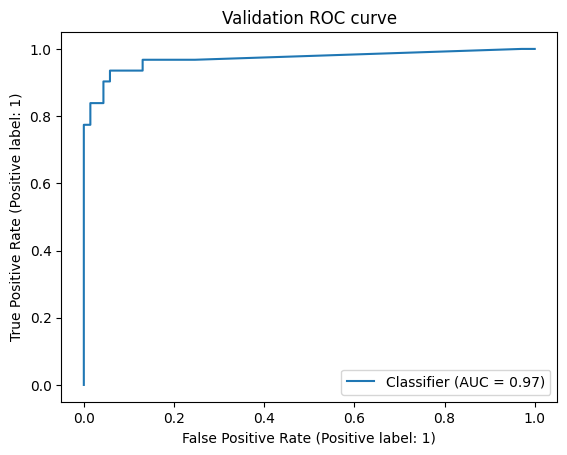

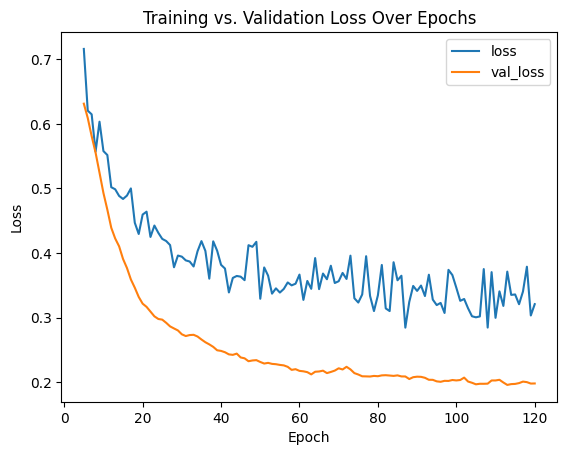

Best Validation Loss: 0.1957


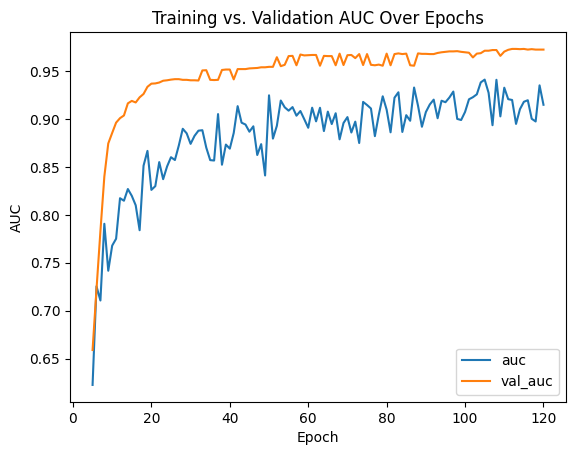

Mean AUC: 0.9274
Best AUC: 0.9731


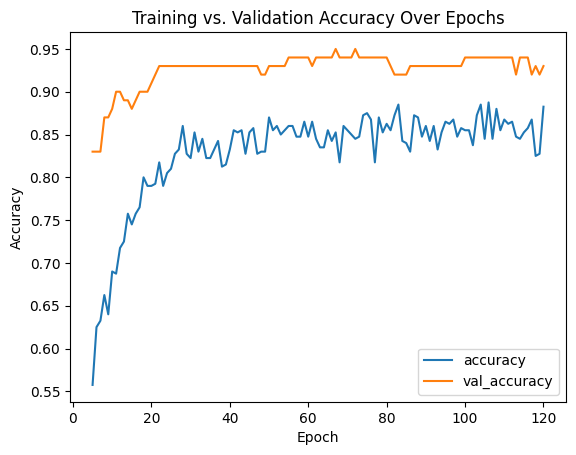

Mean Validation Accuracy: 0.9132
Best Validation Accuracy: 0.9500
Elapsed time: 28.0141 seconds.


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay 
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LogisticRegression

# Starting to count time
tic()

# Compile the model 
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
     metrics=[
         # Using both accuracy and AUC/ROC as metrics
        keras.metrics.BinaryAccuracy(name='accuracy'),         
        keras.metrics.AUC(name='auc', curve='ROC'),            
    ]
)

# Declare early stopping 
early_stopping = EarlyStopping(
    # If there's no improvement for at least 0.001, then drop the data. 
    min_delta=0.001, 
    # Wait 15 epoches before stopping
    patience=15, 
    restore_best_weights=True,
)

# Fit the model
history = model.fit(
    train_X, train_y,
    validation_data=(val_X, val_y),
    epochs=800,
    batch_size=16,
    callbacks = [early_stopping],
    verbose=0
)

# Prediction
preds = model.predict(val_X).ravel()        
RocCurveDisplay.from_predictions(val_y, preds)
# Creating a plot for the ROC curve
plt.title("Validation ROC curve")
plt.show()


# Creating plots for history loss: 
history_df = pd.DataFrame(history.history)
# Start the plot at epoch 5
history_df.loc[5:, ['loss', 'val_loss']].plot()
plt.title("Training vs. Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
# We keep 4 decimal places for convenience
print(
    "Best Validation Loss: {:0.4f}"
    .format(history_df['val_loss'].min())
)
 

# Creating graphs for AUC: 
history_df.loc[5:, ['auc', 'val_auc']].plot()
plt.title("Training vs. Validation AUC Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()
print(
    "Mean AUC: {:0.4f}\nBest AUC: {:0.4f}"
    .format(
        history_df['val_auc'].mean(),
        history_df['val_auc'].max()
    )
)

             
      
# Creating graphs for accuracy: 
history_df.loc[5:, ['accuracy', 'val_accuracy']].plot()
plt.title("Training vs. Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()
print(
    "Mean Validation Accuracy: {:0.4f}\n"
    "Best Validation Accuracy: {:0.4f}"
    .format(
        history_df['val_accuracy'].mean(),
        history_df['val_accuracy'].max()
    )
)

# End counting time
toc()


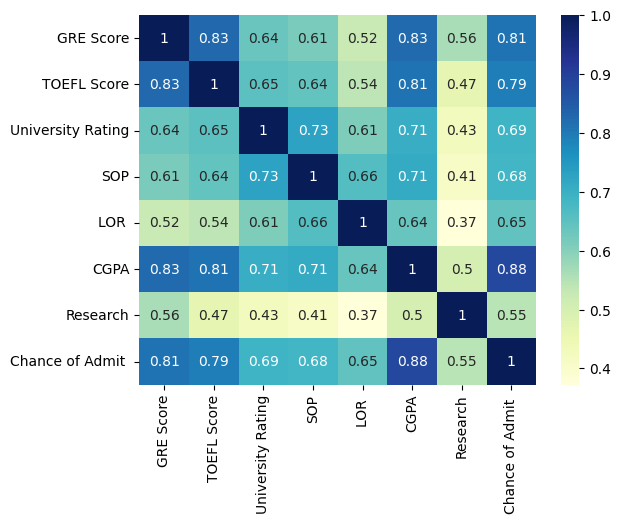

In [6]:
import seaborn as sns

# Create a graph for the correlation between chance of admit to other factors
# Get rid of the first column since it's serial number 
factors = student_data.iloc[:, 1:]
sns.heatmap(factors.corr(),  cmap="YlGnBu", annot=True)
plt.show()


We can see that CGPA has the greatest value of correlation coeffcient, followed by GRE score and TOFEL score. Among all the factors, research has the least affect to chance of admit. 

Now build a logistic regression model: 

Logistic Regression — Validation Accuracy: 0.9400
Logistic Regression — Validation AUC: 0.9762



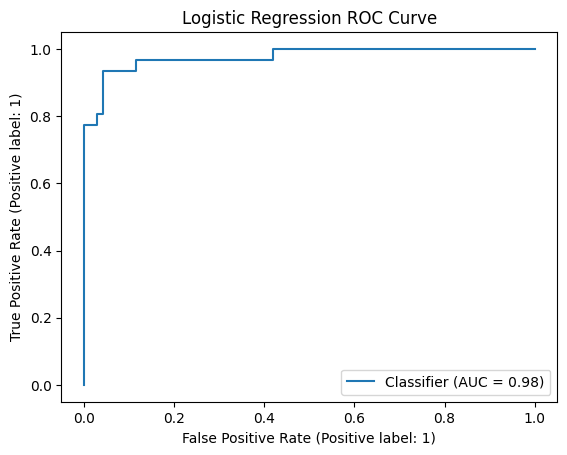

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt

# Define a logistic model
log_model = LogisticRegression(solver='liblinear', random_state=1)

# Fit the logistic regression model
log_model.fit(train_X, train_y)

# Get predictions & probabilities on the validation set
y_pred_log = log_model.predict(val_X)
y_proba_log = log_model.predict_proba(val_X)[:, 1]

# Compute metrics on val set
acc_log = accuracy_score(val_y, y_pred_log)
auc_log = roc_auc_score(val_y, y_proba_log)

# Print the result for accuracy and AUC
print(f"Logistic Regression — Validation Accuracy: {acc_log:.4f}")
print(f"Logistic Regression — Validation AUC: {auc_log:.4f}\n")

# Display the ROC curve grpah
RocCurveDisplay.from_predictions(val_y, y_proba_log)
plt.legend(loc="lower right")
plt.title("Logistic Regression ROC Curve")
plt.show()
